#Installing Libraries

In [4]:
!pip install nibabel
!pip install torch torchvision torchcam torchview
!pip install scikit-learn

#Importing Libraries

In [5]:
import os
import pandas as pd
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchview import draw_graph
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix,cohen_kappa_score,roc_curve,auc
import networkx as nx

#G-Drive Mount

In [7]:
from google.colab import drive
drive.mount('/content/drive')

#Base directory
BASE_DIR = "/content/drive/MyDrive/coinstac-regression-vbm-data-master"

Mounted at /content/drive


#Dataset Loading

In [8]:
df1 = pd.read_csv(os.path.join(BASE_DIR, "site_01+02", "site_01+02_large.csv"))
df2 = pd.read_csv(os.path.join(BASE_DIR, "site_03+04", "site_03+04_large.csv"))

#labels: 0 = Control, 1 = Schizophrenia
def convert_label(x):
    return 0 if str(x).upper() == "TRUE" else 1

for df, site in zip([df1, df2], ["site_01+02", "site_03+04"]):
    df["label"] = df["isControl"].apply(convert_label)
    df["path"] = df["niftifile"].apply(lambda x: os.path.join(BASE_DIR, site, x))

#Merge both sites
df_all = pd.concat([df1, df2], ignore_index=True)

#Checking for existing files dropping the rest
df_all = df_all[df_all["path"].apply(os.path.exists)].reset_index(drop=True)
print(f"Total subjects with valid files: {len(df_all)}")

Total subjects with valid files: 3729


#MRIDataset: Load, Normalize, and Resize 3D MRI Scans for PyTorch

In [9]:
class MRIDataset(Dataset):
    def __init__(self, dataframe, target_shape=(64,64,64)):
        self.df = dataframe
        self.target_shape = target_shape

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = nib.load(row["path"]).get_fdata()
        img = np.nan_to_num(img)

        #Normalize
        img = (img - np.mean(img)) / (np.std(img) + 1e-5)
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  #(1, D,H,W)

        #Resizing if needed
        if self.target_shape is not None:
            img = F.interpolate(img.unsqueeze(0), size=self.target_shape, mode='trilinear', align_corners=False)
            img = img.squeeze(0)

        label = torch.tensor(row["label"], dtype=torch.long)
        return img, label

#Train Test Split

In [10]:
train_df, test_df = train_test_split(df_all, test_size=0.2, stratify=df_all["label"], random_state=42)

train_dataset = MRIDataset(train_df, target_shape=(64,64,64))
test_dataset = MRIDataset(test_df, target_shape=(64,64,64))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

#3D CNN Model


In [11]:
class CNN3D(nn.Module):
    def __init__(self, input_shape=(1,64,64,64)):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv3d(1, 16, 3, padding=1), nn.BatchNorm3d(16), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(16, 32, 3, padding=1), nn.BatchNorm3d(32), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(32, 64, 3, padding=1), nn.BatchNorm3d(64), nn.ReLU(), nn.MaxPool3d(2),
        )
        #Compute flattened size dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            dummy = self.conv_layers(dummy)
            n_features = dummy.numel() // dummy.shape[0]

        self.fc_layers = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        return self.fc_layers(x)


#Training Setup

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN3D(input_shape=(1,64,64,64)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
EPOCHS = 40

#Training Loop

In [13]:
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct = 0.0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    train_acc = correct / len(train_dataset)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(train_loader):.4f} | Acc: {train_acc:.4f}")

Epoch 1/40: 100%|██████████| 746/746 [10:52<00:00,  1.14it/s]


Epoch 1/40 | Loss: 0.6762 | Acc: 0.5702


Epoch 2/40: 100%|██████████| 746/746 [03:09<00:00,  3.94it/s]


Epoch 2/40 | Loss: 0.6396 | Acc: 0.6141


Epoch 3/40: 100%|██████████| 746/746 [03:10<00:00,  3.92it/s]


...

Epoch 38/40 | Loss: 0.1839 | Acc: 0.9182


Epoch 39/40: 100%|██████████| 746/746 [03:07<00:00,  3.98it/s]


Epoch 39/40 | Loss: 0.1804 | Acc: 0.9239


Epoch 40/40: 100%|██████████| 746/746 [03:10<00:00,  3.92it/s]

Epoch 40/40 | Loss: 0.1824 | Acc: 0.9226


#Model Evaluation


=== Test Performance ===
Accuracy (counts) : 0.9223   (Correct: 688 / Total: 746)
Accuracy (sklearn) : 0.9223
F1 Score           : 0.9212
Cohen's Kappa      : 0.8449
AUC                : 0.9877

Classification Report:
               precision    recall  f1-score   support

      Control       0.97      0.88      0.92       398
Schizophrenia       0.87      0.97      0.92       348

     accuracy                           0.92       746
    macro avg       0.92      0.93      0.92       746
 weighted avg       0.93      0.92      0.92       746

Confusion Matrix:
[[349  49]
 [  9 339]]


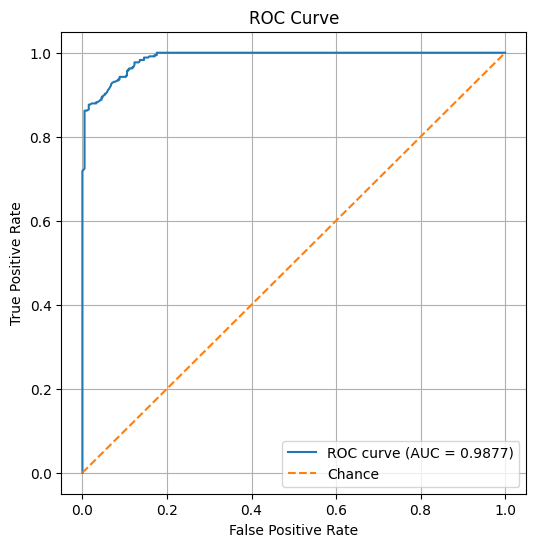

In [14]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    cohen_kappa_score, roc_curve, auc
)
import matplotlib.pyplot as plt

model.eval()
correct, total = 0, 0
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)  # shape: (batch_size, num_classes)

        # preds and probs
        preds = outputs.argmax(dim=1)
        # If binary classification (num_classes == 2), select class-1 prob.
        # If more than 2 classes you'll need a different approach (see note below).
        probs = F.softmax(outputs, dim=1)[:, 1]  # probability for class 1 (Schizophrenia)

        # update counters
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # collect for detailed metrics
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Compute metrics
test_acc_from_counts = correct / total if total > 0 else 0.0
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)
test_kappa = cohen_kappa_score(all_labels, all_preds)

try:
    test_auc = roc_auc_score(all_labels, all_probs)
except ValueError:
    test_auc = float("nan")
    print("Warning: AUC could not be computed (only one class present in all_labels or invalid probs).")

print(f"\n=== Test Performance ===")
print(f"Accuracy (counts) : {test_acc_from_counts:.4f}   (Correct: {correct} / Total: {total})")
print(f"Accuracy (sklearn) : {test_acc:.4f}")
print(f"F1 Score           : {test_f1:.4f}")
print(f"Cohen's Kappa      : {test_kappa:.4f}")
print(f"AUC                : {test_auc:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Control", "Schizophrenia"]))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

# ---- Plot ROC curve ----
if len(np.unique(all_labels)) == 2:
    try:
        fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
        roc_auc_val = auc(fpr, tpr)

        plt.figure(figsize=(6, 6))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
        plt.plot([0, 1], [0, 1], linestyle='--', label='Chance')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()
    except Exception as e:
        print(f"Could not plot ROC curve: {e}")
else:
    print("ROC curve not plotted: need binary labels (found classes: "
          f"{np.unique(all_labels)}). For multiclass, consider one-vs-rest ROC/AUC.")


#Grad-CAM for 3D CNN

In [15]:
class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.device = next(model.parameters()).device
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        #register hooks
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate_cam(self, input_tensor, target_class=None):
        input_tensor = input_tensor.to(self.device)
        self.model.zero_grad()

        outputs = self.model(input_tensor)
        if target_class is None:
            target_class = outputs.argmax(dim=1).item()

        score = outputs[0, target_class]
        score.backward(retain_graph=True)

        #compute weights
        weights = self.gradients.mean(dim=(2,3,4), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        #normalize
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        #upsample to input size
        upsample_size = input_tensor.shape[2:]
        cam_torch = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
        cam_up = F.interpolate(cam_torch, size=upsample_size, mode='trilinear', align_corners=False)
        cam_up = cam_up.squeeze().numpy()

        return cam_up, target_class

#Grad-CAM Visualization


In [16]:
def central_slices(volume):
    D, H, W = volume.shape
    return volume[D//2,:,:], volume[:,H//2,:], volume[:,:,W//2]

def show_gradcam(volume, cam, title="Grad-CAM"):
    #volume and cam are (D,H,W)
    ax_img, cor_img, sag_img = central_slices(volume)
    ax_cam, cor_cam, sag_cam = central_slices(cam)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax in axes.ravel(): ax.axis('off')

    #Original slices
    axes[0,0].imshow(ax_img.T, cmap='gray', origin='lower'); axes[0,0].set_title('Axial Slice')
    axes[0,1].imshow(cor_img.T, cmap='gray', origin='lower'); axes[0,1].set_title('Coronal Slice')
    axes[0,2].imshow(sag_img.T, cmap='gray', origin='lower'); axes[0,2].set_title('Sagittal Slice')

    #Overlay heatmap
    axes[1,0].imshow(ax_img.T, cmap='gray', origin='lower')
    axes[1,0].imshow(ax_cam.T, cmap='hot', alpha=0.5, origin='lower')
    axes[1,0].set_title('Axial + CAM')

    axes[1,1].imshow(cor_img.T, cmap='gray', origin='lower')
    axes[1,1].imshow(cor_cam.T, cmap='hot', alpha=0.5, origin='lower')
    axes[1,1].set_title('Coronal + CAM')

    axes[1,2].imshow(sag_img.T, cmap='gray', origin='lower')
    axes[1,2].imshow(sag_cam.T, cmap='hot', alpha=0.5, origin='lower')
    axes[1,2].set_title('Sagittal + CAM')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

#Visualize Grad-CAM on Test Samples

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


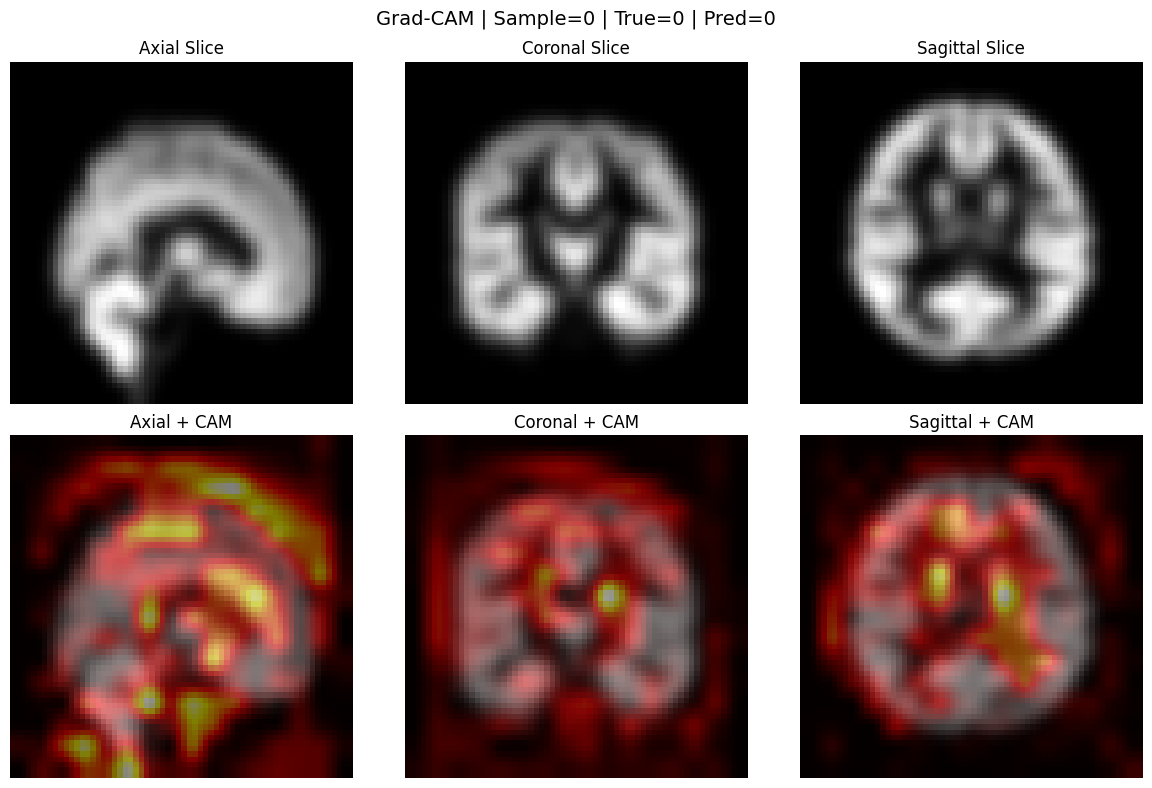

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


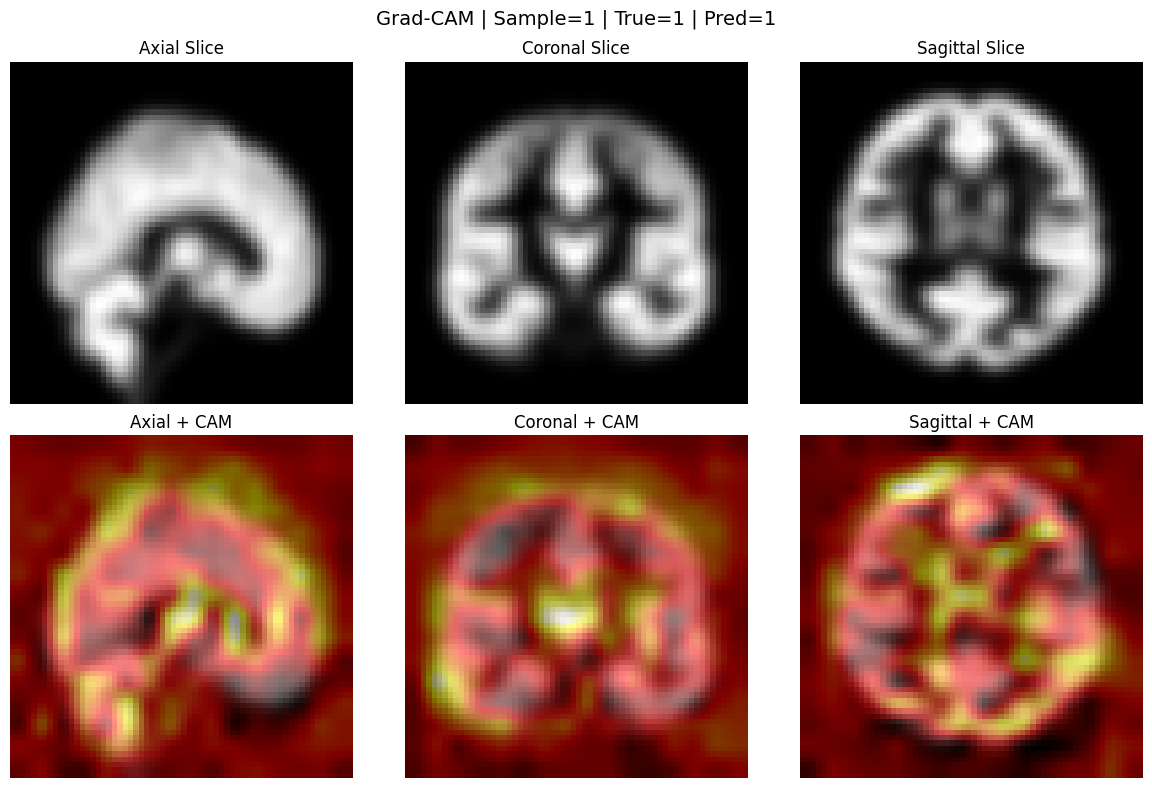

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


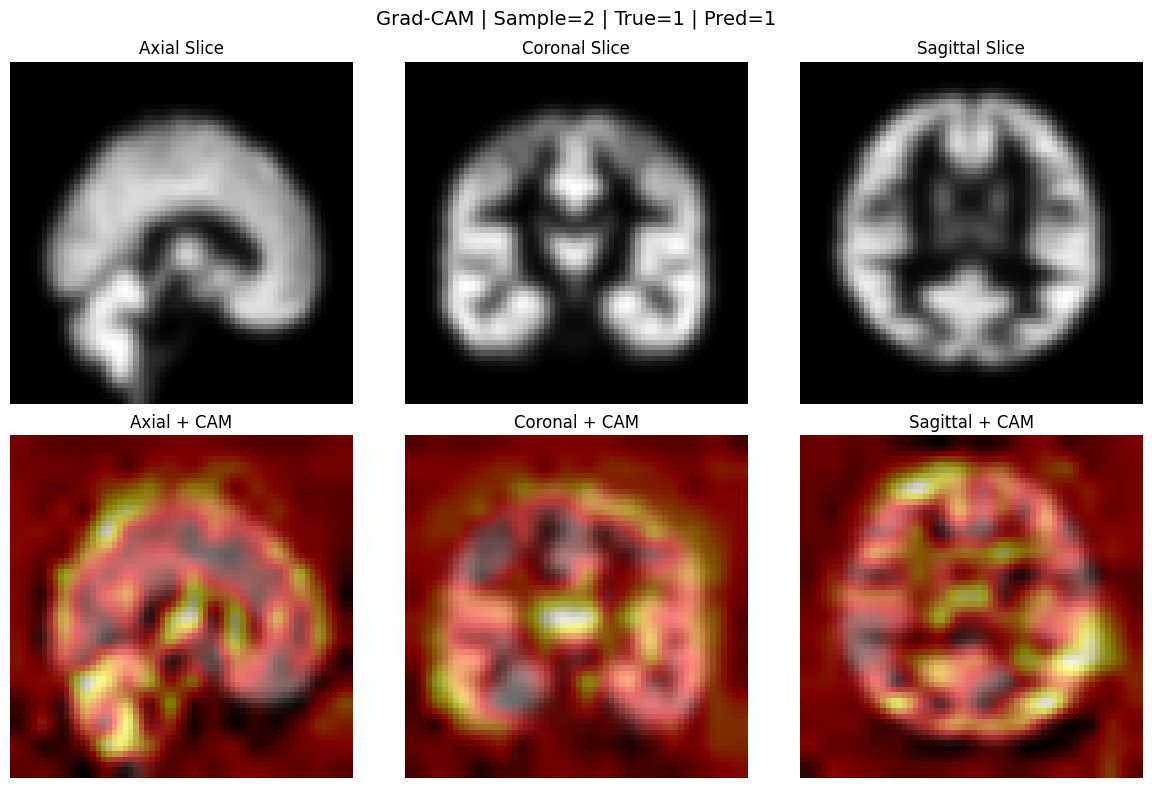

In [17]:
sample_indices = [0, 1, 2]  #indices of test samples

#Choosing the last conv layer
target_layer = model.conv_layers[-4]
gcam = GradCAM3D(model, target_layer)

for idx in sample_indices:
    sample_img, sample_label = test_dataset[idx]
    input_tensor = sample_img.unsqueeze(0).to(device)  #(1,1,D,H,W)

    #generate Grad-CAM
    cam3d, pred_class = gcam.generate_cam(input_tensor)

    #visualize
    volume_np = input_tensor.cpu().squeeze().numpy()
    show_gradcam(volume_np, cam3d, title=f"Grad-CAM | Sample={idx} | True={sample_label.item()} | Pred={pred_class}")


#3D CNN Visualisation


/tmp/ipykernel_7005/1342615588.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


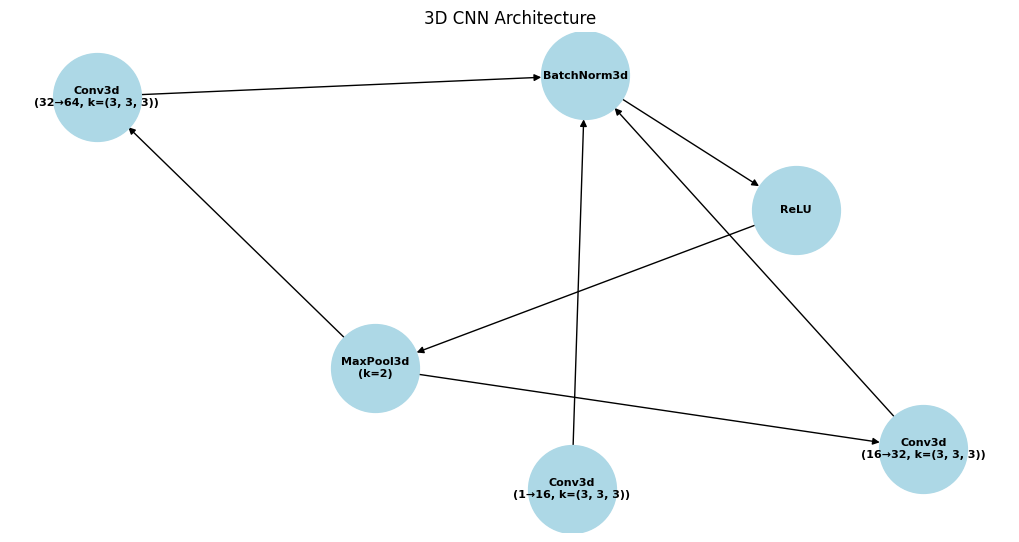

In [18]:
class CNN3D(nn.Module):
    def __init__(self, input_shape=(1,64,64,64)):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv3d(1, 16, 3, padding=1), nn.BatchNorm3d(16), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(16, 32, 3, padding=1), nn.BatchNorm3d(32), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(32, 64, 3, padding=1), nn.BatchNorm3d(64), nn.ReLU(), nn.MaxPool3d(2),
        )

    def forward(self, x):
        return self.conv_layers(x)

# Create a visual graph of convolutional layers
def visualize_conv_architecture(model):
    layers = []
    for i, layer in enumerate(model.conv_layers):
        name = layer.__class__.__name__
        if isinstance(layer, nn.Conv3d):
            layers.append(f"{name}\n({layer.in_channels}→{layer.out_channels}, k={layer.kernel_size})")
        elif isinstance(layer, nn.MaxPool3d):
            layers.append(f"{name}\n(k={layer.kernel_size})")
        elif isinstance(layer, nn.BatchNorm3d):
            layers.append("BatchNorm3d")
        elif isinstance(layer, nn.ReLU):
            layers.append("ReLU")

    G = nx.DiGraph()
    for i in range(len(layers) - 1):
        G.add_edge(layers[i], layers[i+1])

    plt.figure(figsize=(10, 5))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=4000, node_color="lightblue", font_size=8, font_weight="bold", arrows=True)
    plt.title("3D CNN Architecture", fontsize=12)
    plt.tight_layout()
    plt.show()

# Run visualization
model = CNN3D()
visualize_conv_architecture(model)


In [19]:
class CNN3D(nn.Module):
    def __init__(self, input_shape=(1,64,64,64)):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv3d(1, 16, 3, padding=1), nn.BatchNorm3d(16), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(16, 32, 3, padding=1), nn.BatchNorm3d(32), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(32, 64, 3, padding=1), nn.BatchNorm3d(64), nn.ReLU(), nn.MaxPool3d(2),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            dummy = self.conv_layers(dummy)
            n_features = dummy.numel() // dummy.shape[0]
        self.fc_layers = nn.Sequential(
            nn.Linear(n_features, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, 2)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        return self.fc_layers(x)

model = CNN3D()

# Draw and save model graph as image
graph = draw_graph(model, input_size=(1, 1, 64, 64, 64), expand_nested=True)
graph.visual_graph.render(filename="CNN3D_architecture", format="png")


'CNN3D_architecture.png'

In [20]:
print(model)

CNN3D(
  (conv_layers): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=32768, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=F

In [21]:
import pickle

# save entire model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ model.pkl saved successfully")

✅ model.pkl saved successfully


In [23]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import pickle
import torch

with open("model.pkl", "rb") as f:
    model = pickle.load(f)

# ensure it's on CPU
model = model.to("cpu")
model.eval()

print("✅ Loaded model from pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'model.pkl'